# **Delhi Crime Predictive Model**
This model Predicts the **"POSSIBILITY"** of any crime to happen in an area on a perticular type of day/season/timeline.

## Step 1 - Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## Step 2 - Load Dataset

In [3]:
# importing data from Dataset
data = pd.read_csv('/content/delhi_crime_dataset.csv')

print('Shape of dataset:', data.shape)
print('\nColumn Names:', list(data.columns))
print('\nFirst 5 rows:')
data.head()

Shape of dataset: (1260, 35)

Column Names: ['year', 'month', 'district', 'latitude', 'longitude', 'population', 'area_sq_km', 'population_density', 'police_stations', 'literacy_rate', 'unemployment_rate', 'avg_temperature_C', 'avg_rainfall_mm', 'is_festive_month', 'is_summer', 'is_monsoon', 'quarter', 'crime_murder', 'crime_rape', 'crime_robbery', 'crime_mv_theft', 'crime_burglary', 'crime_snatching', 'crime_hurt', 'crime_house_theft', 'crime_other_theft', 'crime_dacoity', 'crime_kidnapping', 'total_crimes', 'crime_rate_per_lakh', 'risk_level', 'risk_score', 'crime_density', 'prev_month_crimes', 'rolling_3m_avg']

First 5 rows:


,year,month,district,latitude,longitude,population,area_sq_km,population_density,police_stations,literacy_rate,...,crime_other_theft,crime_dacoity,crime_kidnapping,total_crimes,crime_rate_per_lakh,risk_level,risk_score,crime_density,prev_month_crimes,rolling_3m_avg
0,2016,1,Central,28.6469,77.2164,910000,30,30333.3,9,84.2,...,306,0,26,710,78.02,MEDIUM,2,23.666667,NaN,710.0
1,2016,2,Central,28.6469,77.2164,910000,30,30333.3,9,84.2,...,311,0,27,667,73.30,MEDIUM,2,22.233333,710.0,688.5
2,2016,3,Central,28.6469,77.2164,910000,30,30333.3,9,84.2,...,341,0,26,726,79.78,MEDIUM,2,24.200000,667.0,701.0
3,2016,4,Central,28.6469,77.2164,910000,30,30333.3,9,84.2,...,365,0,29,758,83.30,MEDIUM,2,25.266667,726.0,717.0
4,2016,5,Central,28.6469,77.2164,910000,30,30333.3,9,84.2,...,290,0,34,730,80.22,MEDIUM,2,24.333333,758.0,738.0


## Step 3 - Dataset Info & Basic Details

In [4]:
# Check data types and non-null counts
print('Dataset Info:')
print(data.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 1260 non-null   int64  
 1   month                1260 non-null   int64  
 2   district             1260 non-null   object 
 3   latitude             1260 non-null   float64
 4   longitude            1260 non-null   float64
 5   population           1260 non-null   int64  
 6   area_sq_km           1260 non-null   int64  
 7   population_density   1260 non-null   float64
 8   police_stations      1260 non-null   int64  
 9   literacy_rate        1260 non-null   float64
 10  unemployment_rate    1260 non-null   float64
 11  avg_temperature_C    1260 non-null   float64
 12  avg_rainfall_mm      1260 non-null   float64
 13  is_festive_month     1260 non-null   int64  
 14  is_summer            1260 non-null   int64  
 15  is_monsoon           126

In [5]:
# Statistical summary
print('Statistical Summary:')
data.describe()

Statistical Summary:


,year,month,latitude,longitude,population,area_sq_km,population_density,police_stations,literacy_rate,unemployment_rate,...,crime_house_theft,crime_other_theft,crime_dacoity,crime_kidnapping,total_crimes,crime_rate_per_lakh,risk_score,crime_density,prev_month_crimes,rolling_3m_avg
count,1260.000000,1260.000000,1260.000000,1260.000000,1.260000e+03,1260.000000,1260.000000,1260.00000,1260.000000,1260.000000,...,1260.000000,1260.000000,1260.0,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1245.000000,1260.000000
mean,2019.000000,6.500000,28.660267,77.165127,1.413405e+06,167.466667,14583.160000,9.80000,82.533333,6.080000,...,35.762698,705.711111,0.0,30.265873,1095.079365,84.638873,2.010317,11.539495,1100.508434,1098.535635
std,2.000794,3.453423,0.077670,0.106275,5.940031e+05,142.594482,10843.589269,2.16727,3.173360,1.239416,...,29.238197,308.010742,0.0,11.091931,399.348592,28.384988,0.819183,8.500950,398.147559,387.620606
min,2016.000000,1.000000,28.524400,76.965400,2.570000e+05,30.000000,3000.000000,6.00000,77.600000,3.800000,...,2.000000,92.000000,0.0,4.000000,152.000000,26.430000,1.000000,1.088095,152.000000,157.300000
25%,2017.000000,3.750000,28.593300,77.078500,9.100000e+05,60.000000,5333.300000,8.00000,79.800000,5.100000,...,14.000000,483.000000,0.0,23.000000,839.750000,64.082500,1.000000,5.000000,847.000000,861.300000
50%,2019.000000,6.500000,28.654000,77.205000,1.500000e+06,102.000000,10971.600000,9.00000,82.100000,5.900000,...,20.000000,681.500000,0.0,30.000000,1104.500000,81.055000,2.000000,9.141245,1113.000000,1105.850000
75%,2021.000000,9.250000,28.730000,77.282900,1.709346e+06,249.000000,26708.500000,11.00000,84.800000,7.200000,...,55.250000,910.250000,0.0,38.000000,1363.000000,104.047500,3.000000,15.877083,1364.000000,1366.850000
max,2022.000000,12.000000,28.820000,77.317800,2.731929e+06,445.000000,37380.000000,15.00000,89.700000,8.100000,...,136.000000,1848.000000,0.0,61.000000,2440.000000,185.880000,3.000000,41.233333,2440.000000,2244.000000


In [6]:
# Check for missing values
print('Missing Values in each column:')
print(data.isnull().sum())

Missing Values in each column:
year                    0
month                   0
district                0
latitude                0
longitude               0
population              0
area_sq_km              0
population_density      0
police_stations         0
literacy_rate           0
unemployment_rate       0
avg_temperature_C       0
avg_rainfall_mm         0
is_festive_month        0
is_summer               0
is_monsoon              0
quarter                 0
crime_murder            0
crime_rape              0
crime_robbery           0
crime_mv_theft          0
crime_burglary          0
crime_snatching         0
crime_hurt              0
crime_house_theft       0
crime_other_theft       0
crime_dacoity           0
crime_kidnapping        0
total_crimes            0
crime_rate_per_lakh     0
risk_level              0
risk_score              0
crime_density           0
prev_month_crimes      15
rolling_3m_avg          0
dtype: int64


## Step 4 - Data Cleaning

In [7]:
# Fill missing values in lag columns (first month has no previous month)
data['prev_month_crimes'].fillna(data['prev_month_crimes'].median(), inplace=True)
data['rolling_3m_avg'].fillna(data['rolling_3m_avg'].median(), inplace=True)

# Check unique values in target column
print('Risk Level Categories:', data['risk_level'].unique())
print('\nCount of each Risk Level:')
print(data['risk_level'].value_counts())

Risk Level Categories: ['MEDIUM' 'HIGH' 'LOW']

Count of each Risk Level:
risk_level
HIGH      429
LOW       416
MEDIUM    415
Name: count, dtype: int64


In [8]:
# Check for duplicate rows
print('Duplicate Rows:', data.duplicated().sum())

# Drop duplicates if any
data.drop_duplicates(inplace=True)
print('Shape after cleaning:', data.shape)

Duplicate Rows: 0
Shape after cleaning: (1260, 35)


## Step 5 - Data Analysis and Visualization

### Univariate Analysis

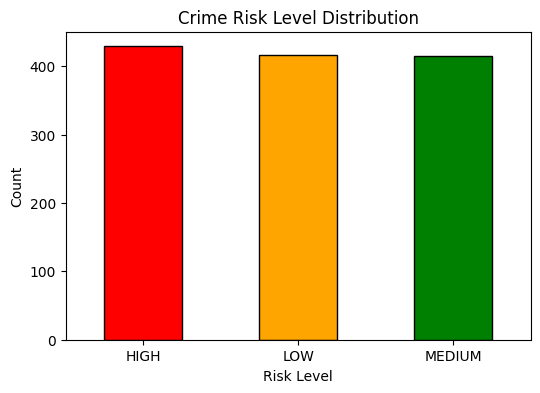

In [9]:
# Bar Chart - Risk Level Distribution
plt.figure(figsize=(6,4))
data['risk_level'].value_counts().plot(kind='bar', color=['red','orange','green'], edgecolor='black')
plt.title('Crime Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

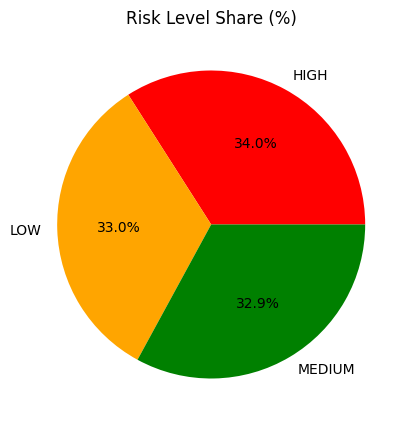

In [10]:
# Pie Chart - Risk Level Share
plt.figure(figsize=(5,5))
data['risk_level'].value_counts().plot.pie(autopct='%1.1f%%', colors=['red','orange','green'])
plt.title('Risk Level Share (%)')
plt.ylabel('')
plt.show()

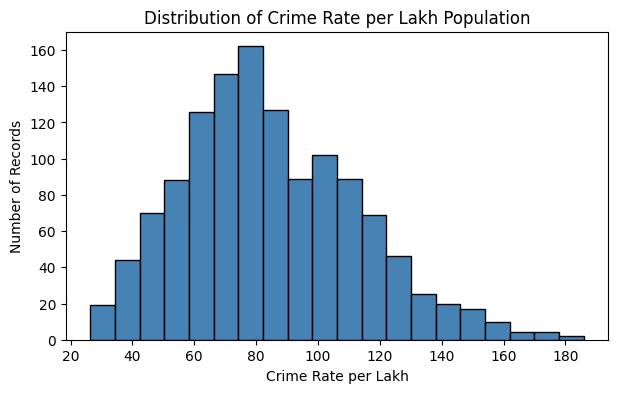

In [11]:
# Histogram - Crime Rate per Lakh Distribution
plt.figure(figsize=(7,4))
plt.hist(data['crime_rate_per_lakh'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Crime Rate per Lakh Population')
plt.xlabel('Crime Rate per Lakh')
plt.ylabel('Number of Records')
plt.show()

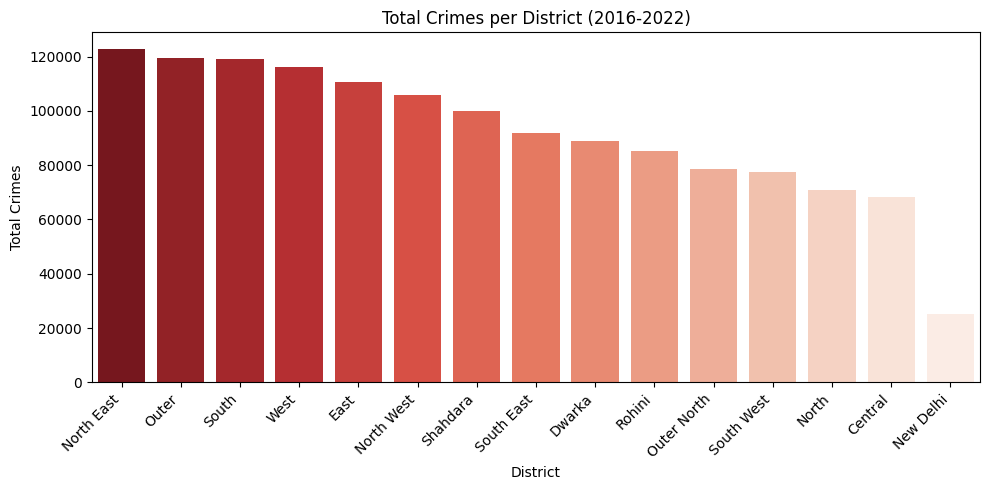

In [12]:
# Bar Chart - Total Crimes per District
plt.figure(figsize=(10,5))
district_crimes = data.groupby('district')['total_crimes'].sum().sort_values(ascending=False)
sns.barplot(x=district_crimes.index, y=district_crimes.values, palette='Reds_r')
plt.title('Total Crimes per District (2016-2022)')
plt.xlabel('District')
plt.ylabel('Total Crimes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bivariate Analysis

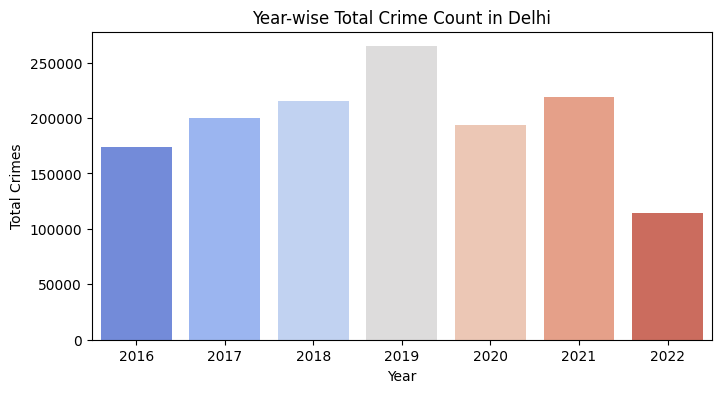

In [13]:
# Bar Chart - Year-wise Total Crime
plt.figure(figsize=(8,4))
yearly = data.groupby('year')['total_crimes'].sum()
sns.barplot(x=yearly.index, y=yearly.values, palette='coolwarm')
plt.title('Year-wise Total Crime Count in Delhi')
plt.xlabel('Year')
plt.ylabel('Total Crimes')
plt.show()

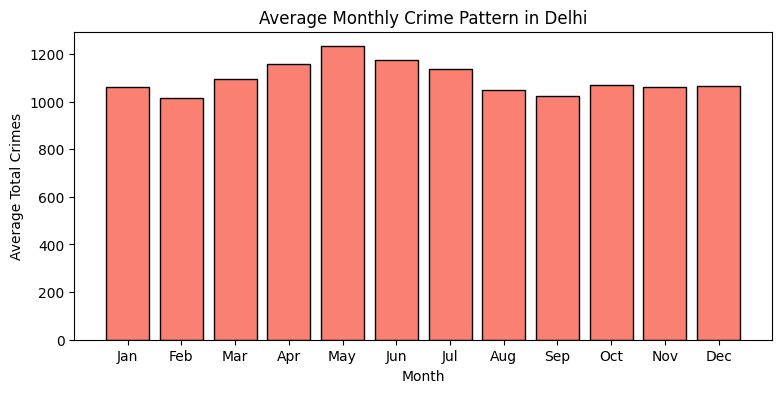

In [14]:
# Bar Chart - Monthly Average Crime
plt.figure(figsize=(9,4))
monthly = data.groupby('month')['total_crimes'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.bar(month_names, monthly.values, color='salmon', edgecolor='black')
plt.title('Average Monthly Crime Pattern in Delhi')
plt.xlabel('Month')
plt.ylabel('Average Total Crimes')
plt.show()

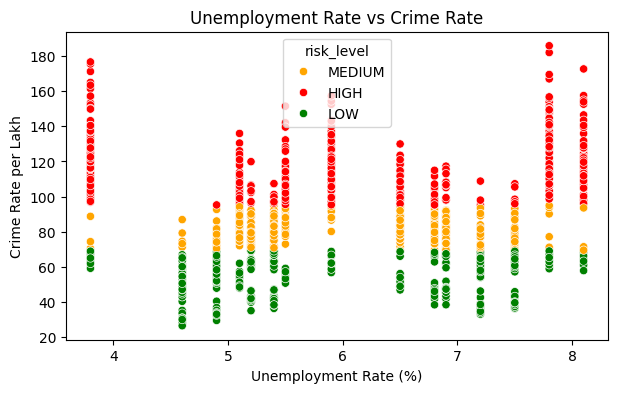

In [15]:
# Scatter Plot - Unemployment Rate vs Crime Rate
plt.figure(figsize=(7,4))
sns.scatterplot(data=data, x='unemployment_rate', y='crime_rate_per_lakh', hue='risk_level',
                palette={'LOW':'green','MEDIUM':'orange','HIGH':'red'})
plt.title('Unemployment Rate vs Crime Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Crime Rate per Lakh')
plt.show()

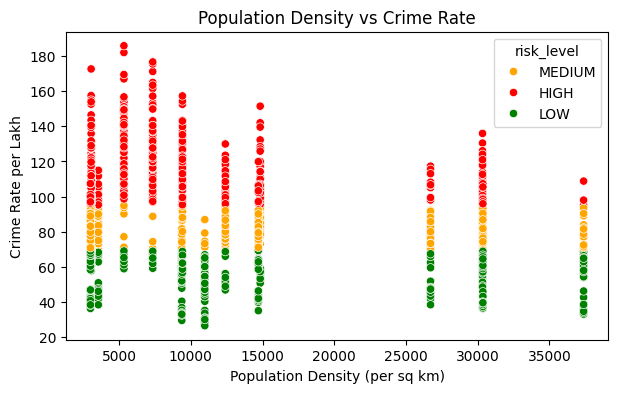

In [16]:
# Scatter Plot - Population Density vs Crime Rate
plt.figure(figsize=(7,4))
sns.scatterplot(data=data, x='population_density', y='crime_rate_per_lakh', hue='risk_level',
                palette={'LOW':'green','MEDIUM':'orange','HIGH':'red'})
plt.title('Population Density vs Crime Rate')
plt.xlabel('Population Density (per sq km)')
plt.ylabel('Crime Rate per Lakh')
plt.show()

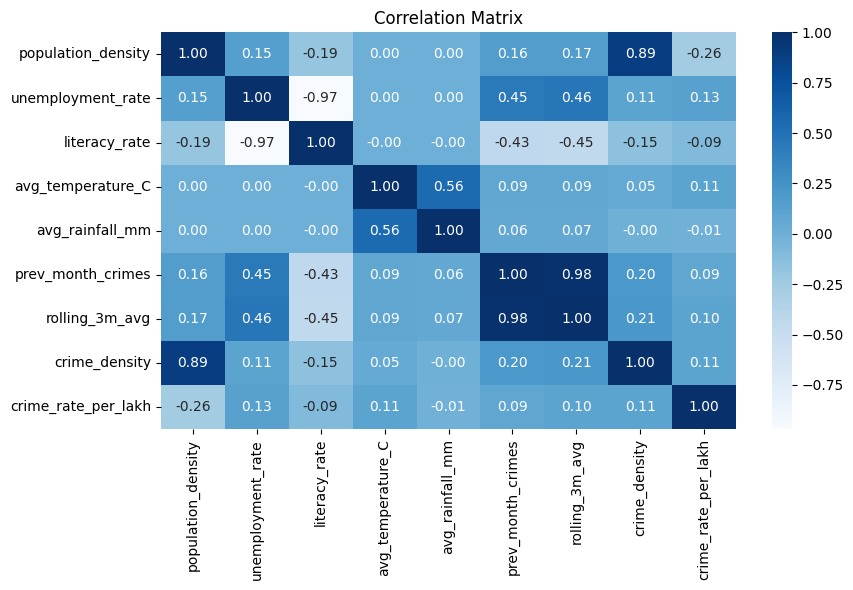

In [17]:
# Correlation Matrix
plt.figure(figsize=(9,6))
cols = ['population_density','unemployment_rate','literacy_rate',
        'avg_temperature_C','avg_rainfall_mm','prev_month_crimes',
        'rolling_3m_avg','crime_density','crime_rate_per_lakh']
sns.heatmap(data[cols].corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

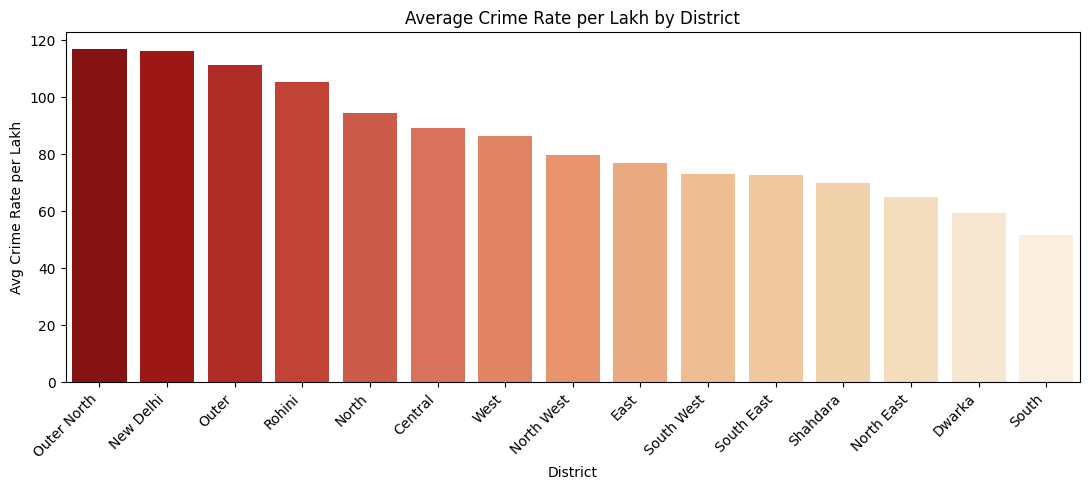

In [18]:
# Average Crime Rate by District - grouped barplot
plt.figure(figsize=(11,5))
avg_risk = data.groupby('district')['crime_rate_per_lakh'].mean().sort_values(ascending=False)
sns.barplot(x=avg_risk.index, y=avg_risk.values, palette='OrRd_r')
plt.title('Average Crime Rate per Lakh by District')
plt.xlabel('District')
plt.ylabel('Avg Crime Rate per Lakh')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

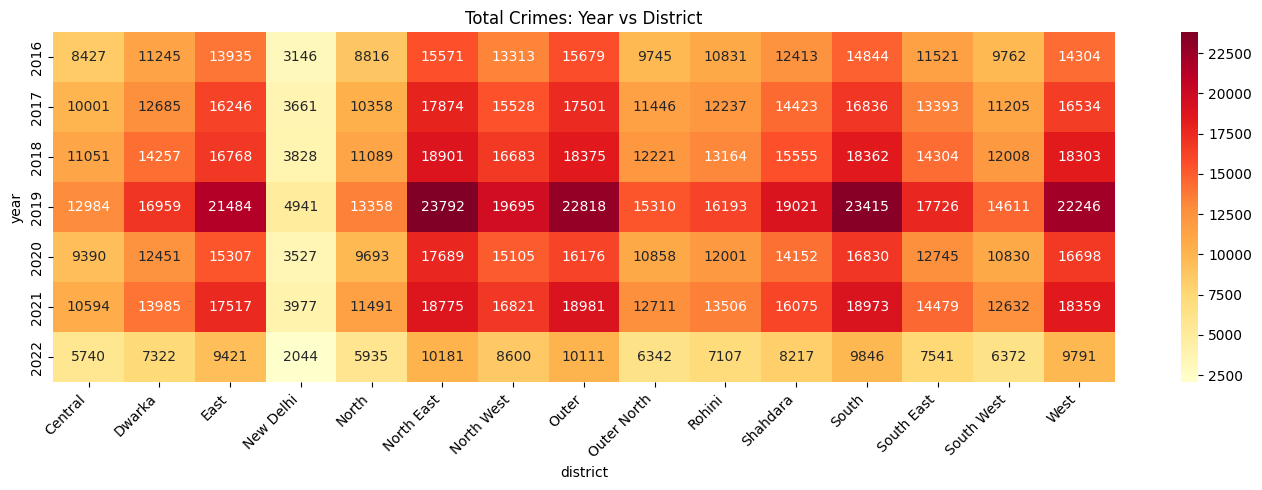

In [19]:
# Pivot Heatmap - Avg Crime by Year and District
pivot = data.pivot_table(values='total_crimes', index='year', columns='district', aggfunc='sum')
plt.figure(figsize=(14,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Total Crimes: Year vs District')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 6 - Preparing Features for Model

In [20]:
# Encode the district column (convert text to numbers)
le = LabelEncoder()
data['district_encoded'] = le.fit_transform(data['district'])

print('District Encoding:')
for name, code in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {name} --> {code}')

District Encoding:
  Central --> 0
  Dwarka --> 1
  East --> 2
  New Delhi --> 3
  North --> 4
  North East --> 5
  North West --> 6
  Outer --> 7
  Outer North --> 8
  Rohini --> 9
  Shahdara --> 10
  South --> 11
  South East --> 12
  South West --> 13
  West --> 14


In [21]:
# Define Features (X) and Target (y)

# NOTE: We do NOT use total_crimes or crime_rate_per_lakh as features
# because risk_level was made from those columns (that would be cheating)

X = data[['district_encoded', 'month', 'year',
          'population_density', 'literacy_rate', 'unemployment_rate',
          'avg_temperature_C', 'avg_rainfall_mm',
          'is_summer', 'is_festive_month',
          'prev_month_crimes', 'rolling_3m_avg', 'crime_density']]

y = data['risk_level']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nTarget Classes:', y.unique())

Features shape: (1260, 13)
Target shape: (1260,)

Target Classes: ['MEDIUM' 'HIGH' 'LOW']


## Step 7 - Train Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape[0])
print('Testing set size :', X_test.shape[0])

Training set size: 1008
Testing set size : 252


## Step 8 - Model 1: Decision Tree Classifier

In [23]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)
print('Decision Tree Accuracy:', round(dt_accuracy * 100, 2), '%')
print('\nClassification Report:')
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 76.19 %

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.70      0.93      0.80        87
         LOW       0.94      0.81      0.87        83
      MEDIUM       0.68      0.54      0.60        82

    accuracy                           0.76       252
   macro avg       0.77      0.76      0.76       252
weighted avg       0.77      0.76      0.76       252



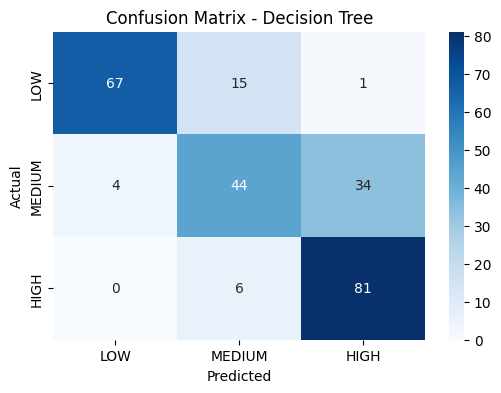

In [24]:
# Confusion Matrix - Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred, labels=['LOW','MEDIUM','HIGH'])
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['LOW','MEDIUM','HIGH'],
            yticklabels=['LOW','MEDIUM','HIGH'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Step 9 - Model 2: Random Forest Classifier

In [25]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
print('Random Forest Accuracy:', round(rf_accuracy * 100, 2), '%')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 96.43 %

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.97      0.98      0.97        87
         LOW       0.98      0.98      0.98        83
      MEDIUM       0.95      0.94      0.94        82

    accuracy                           0.96       252
   macro avg       0.96      0.96      0.96       252
weighted avg       0.96      0.96      0.96       252



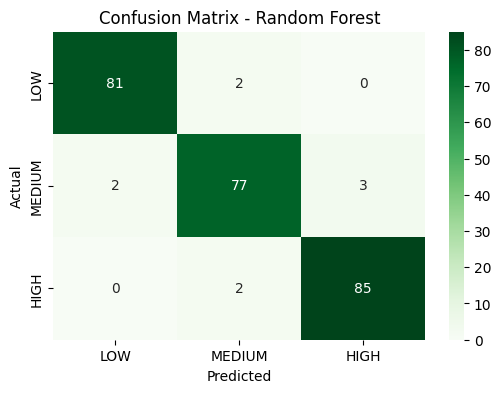

In [26]:
# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, rf_pred, labels=['LOW','MEDIUM','HIGH'])
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['LOW','MEDIUM','HIGH'],
            yticklabels=['LOW','MEDIUM','HIGH'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Step 10 - Model Comparison

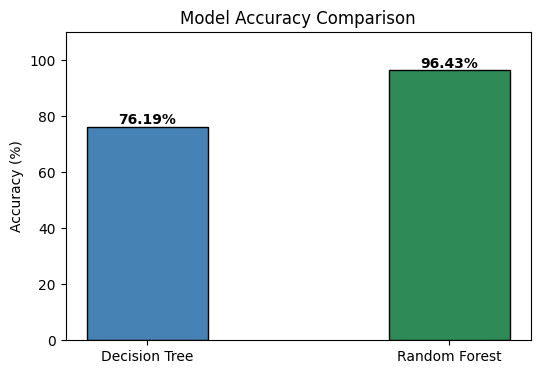

Decision Tree Accuracy : 76.19047619047619 %
Random Forest Accuracy : 96.42857142857143 %

Best Model: Random Forest


In [27]:
# Compare both models side by side
models      = ['Decision Tree', 'Random Forest']
accuracies  = [round(dt_accuracy*100, 2), round(rf_accuracy*100, 2)]

plt.figure(figsize=(6,4))
bars = plt.bar(models, accuracies, color=['steelblue','seagreen'], edgecolor='black', width=0.4)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(bar.get_height()) + '%', ha='center', fontweight='bold')
plt.show()

print('Decision Tree Accuracy :', dt_accuracy*100, '%')
print('Random Forest Accuracy :', rf_accuracy*100, '%')
if rf_accuracy >= dt_accuracy:
    print('\nBest Model: Random Forest')
else:
    print('\nBest Model: Decision Tree')

## Step 11 - Feature Importance (Random Forest)

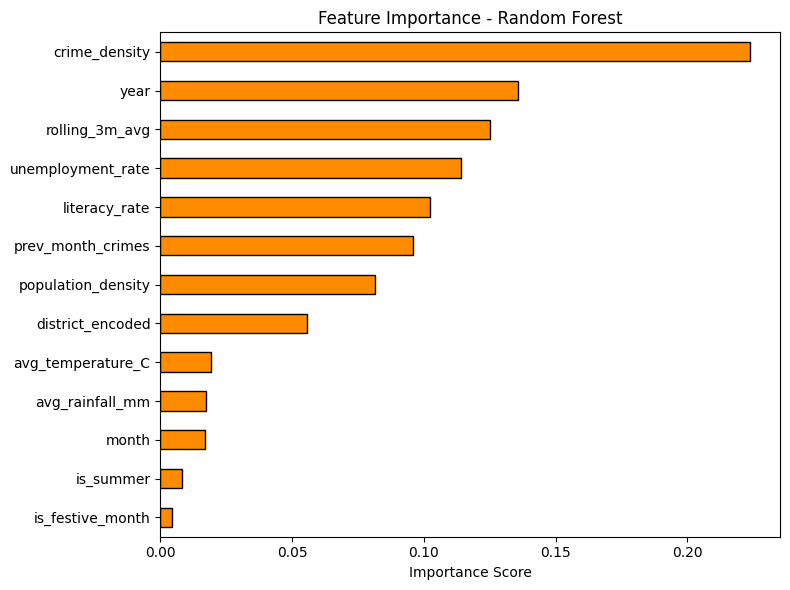

In [28]:
# Which features matter the most?
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 12 - Sample Prediction

In [29]:
# Predict crime risk for a specific district and month
# Change the values below to test different scenarios

sample = pd.DataFrame([{
    'district_encoded' : 7,      # 7 = North East Delhi
    'month'            : 5,      # May
    'year'             : 2022,
    'population_density': 37380,
    'literacy_rate'    : 79.8,
    'unemployment_rate': 7.2,
    'avg_temperature_C': 35.9,
    'avg_rainfall_mm'  : 18.0,
    'is_summer'        : 1,
    'is_festive_month' : 0,
    'prev_month_crimes': 2000,
    'rolling_3m_avg'   : 1900,
    'crime_density'    : 33.3
}])

prediction = rf_model.predict(sample)[0]
print('--- Sample Prediction ---')
print('District : North East Delhi')
print('Month    : May 2022')
print('Predicted Crime Risk Level:', prediction)

--- Sample Prediction ---
District : North East Delhi
Month    : May 2022
Predicted Crime Risk Level: LOW


## Step 13 - Project Summary

In [30]:
print('Dataset   : Delhi Crime Data (2016-2022)')
print('Records   :', data.shape[0])
print('Features  : 13')
print('Target    : Crime Risk Level (LOW / MEDIUM / HIGH)')
print()
print('Model Results:')
print('  Decision Tree Accuracy :', round(dt_accuracy*100, 2), '%')
print('  Random Forest Accuracy :', round(rf_accuracy*100, 2), '%')
print()
if rf_accuracy >= dt_accuracy:
    print('Best Model : Random Forest')
else:
    print('Best Model : Decision Tree')
print()
print('Key Observations:')
print('  - North East, South and Outer Delhi are highest risk zones')
print('  - Summer months (May-Jun) show highest crime activity')
print('  - Unemployment and population density are key predictors')
print('  - prev_month_crimes is the most important feature')
print('============================================')

Dataset   : Delhi Crime Data (2016-2022)
Records   : 1260
Features  : 13
Target    : Crime Risk Level (LOW / MEDIUM / HIGH)

Model Results:
  Decision Tree Accuracy : 76.19 %
  Random Forest Accuracy : 96.43 %

Best Model : Random Forest

Key Observations:
  - North East, South and Outer Delhi are highest risk zones
  - Summer months (May-Jun) show highest crime activity
  - Unemployment and population density are key predictors
  - prev_month_crimes is the most important feature
